# Fetal Head Clinical AI — Phase 4b v10: Temporal Model Pruning

**Goal:** Apply iterative Hybrid Crossover structural pruning to the Phase 2 TemporalFetaSegNet backbone, using the same v10 iterative prune→FT cycle framework from Phase 4a.

**Key difference from Phase 4a:** The pruned model is `model.backbone` (the ResidualUNetDS inside TemporalFetaSegNet), while the temporal attention module remains untouched. Evaluation uses cine clips with temporal Dice, and FT uses the Phase 2 temporal training loop.

## 0. Setup

In [1]:
!pip install albumentations==1.4.0 thop onnx onnxruntime-gpu onnxscript --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 19.7 MB/s eta 0:00:00


In [2]:
import os, json, random, shutil, copy, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from skimage.measure import label, regionprops

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR   = Path('/content/drive/MyDrive/fetal_head_clinical_ai')
PHASE0_CKPT   = PROJECT_DIR / 'checkpoints' / 'phase0' / 'best_model.pth'
PHASE2_CKPT   = PROJECT_DIR / 'checkpoints' / 'phase2' / 'best_model.pth'
CINE_DIR      = PROJECT_DIR / 'cine_dataset'
CKPT_DIR      = PROJECT_DIR / 'checkpoints' / 'phase4b'
RESULTS_DIR   = PROJECT_DIR / 'results' / 'phase4b'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert PHASE0_CKPT.exists(), 'Phase 0 checkpoint missing'
assert PHASE2_CKPT.exists(), 'Phase 2 checkpoint missing'
assert (CINE_DIR / 'metadata.csv').exists(), 'Phase 1 cine dataset missing'

# Config
INPUT_H, INPUT_W = 256, 384
N_FRAMES         = 16
BATCH_SIZE       = 4
NUM_WORKERS      = 2

# -- Pruning config (same as Phase 4a) --
DICE_DROP_MAX    = 0.04
MAE_INCREASE_MAX = 1.50
HARD_FLOORS = {
    'enc3': 64, 'enc4': 128, 'bottleneck': 256, 'dec4': 128, 'dec3': 64,
}
ILR_W = {'rms': 0.6, 'bn_gamma': 0.4, 'hrank': 0.2}

# -- FT config --
FT_EPOCHS     = 30
FT_LR         = 1e-4
KD_ALPHA      = 0.5
KD_TEMP       = 4.0

print('Config ready.')
print(f'Pruning: Dice drop <={DICE_DROP_MAX*100:.0f}pp | MAE increase <={MAE_INCREASE_MAX}mm')
print(f'Hard floors: {HARD_FLOORS}')

Mounted at /content/drive
Config ready.
Pruning: Dice drop <=4pp | MAE increase <=1.5mm
Hard floors: {'enc3': 64, 'enc4': 128, 'bottleneck': 256, 'dec4': 128, 'dec3': 64}


## 1. Model Architecture

Same ResidualUNetDS backbone + TemporalAttentionModule + TemporalFetaSegNet from Phase 2.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)


class ResidualUNetDS(nn.Module):
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        b = base_ch
        self.enc1 = ResidualBlock(in_ch, b)
        self.enc2 = ResidualBlock(b,   b*2)
        self.enc3 = ResidualBlock(b*2, b*4)
        self.enc4 = ResidualBlock(b*4, b*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ResidualBlock(b*8, b*16)
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = ResidualBlock(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3 = ResidualBlock(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2 = ResidualBlock(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1 = ResidualBlock(b*2,  b)
        self.final  = nn.Conv2d(b, 1, 1)
        self.aux_d3 = nn.Conv2d(b*4, 1, 1)
        self.aux_d2 = nn.Conv2d(b*2, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        main = self.final(d1)
        if self.training:
            aux3 = torch.sigmoid(F.interpolate(self.aux_d3(d3), size=x.shape[2:], mode='bilinear', align_corners=False))
            aux2 = torch.sigmoid(F.interpolate(self.aux_d2(d2), size=x.shape[2:], mode='bilinear', align_corners=False))
            return main, aux3, aux2
        return main

    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        return bn, (e1, e2, e3, e4)

    def decode(self, bn, skips):
        e1, e2, e3, e4 = skips
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)


class TemporalAttentionModule(nn.Module):
    def __init__(self, bottleneck_ch=512, n_frames=16, n_heads=8, dropout=0.1):
        super().__init__()
        self.bottleneck_ch = bottleneck_ch
        self.n_frames = n_frames
        self.attn_dim = 256
        self.proj_in  = nn.Linear(bottleneck_ch, self.attn_dim)
        self.pos_encoding = nn.Parameter(torch.randn(1, n_frames, self.attn_dim) * 0.02)
        self.attn = nn.MultiheadAttention(embed_dim=self.attn_dim, num_heads=n_heads,
                                          dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(self.attn_dim)
        self.ff = nn.Sequential(
            nn.Linear(self.attn_dim, self.attn_dim * 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(self.attn_dim * 2, self.attn_dim),
        )
        self.norm2 = nn.LayerNorm(self.attn_dim)
        self.proj_out = nn.Sequential(nn.Linear(self.attn_dim, bottleneck_ch), nn.Sigmoid())
        self._init_weights()

    def _init_weights(self):
        nn.init.constant_(self.proj_out[0].bias, 1.0)

    def forward(self, bottleneck_seq):
        B, T, C, h, w = bottleneck_seq.shape
        pooled = bottleneck_seq.mean(dim=(-2, -1))
        x = self.proj_in(pooled)
        x = x + self.pos_encoding[:, :T, :]
        attn_out, attn_weights = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        mod_weights = self.proj_out(x).unsqueeze(-1).unsqueeze(-1)
        attended_seq = bottleneck_seq * mod_weights
        return attended_seq, attn_weights


class TemporalFetaSegNet(nn.Module):
    def __init__(self, backbone, attn_module):
        super().__init__()
        self.backbone = backbone
        self.attn     = attn_module

    def forward(self, clip):
        B, T, C, H, W = clip.shape
        clip_flat = clip.view(B * T, C, H, W)
        bottlenecks, skips_flat = self.backbone.encode(clip_flat)
        _, Cbn, hbn, wbn = bottlenecks.shape
        bn_seq = bottlenecks.view(B, T, Cbn, hbn, wbn)
        bn_attended, attn_weights = self.attn(bn_seq)
        bn_attended_flat = bn_attended.view(B * T, Cbn, hbn, wbn)
        logits_flat = self.backbone.decode(bn_attended_flat, skips_flat)
        logits = logits_flat.view(B, T, 1, H, W)
        return logits, attn_weights


# Load Phase 2 model
backbone = ResidualUNetDS(in_ch=1, base_ch=32)
attn_module = TemporalAttentionModule(bottleneck_ch=512, n_frames=N_FRAMES, n_heads=8)
phase2_model = TemporalFetaSegNet(backbone, attn_module).to(DEVICE)

ckpt = torch.load(str(PHASE2_CKPT), map_location='cpu')
phase2_model.load_state_dict(ckpt['model_state_dict'])
print(f'Phase 2 model loaded (epoch {ckpt["epoch"]}, stage {ckpt["stage"]}, val Dice {ckpt["val_dice"]*100:.2f}%)')

total_params    = sum(p.numel() for p in phase2_model.parameters())
backbone_params = sum(p.numel() for p in phase2_model.backbone.parameters())
attn_params     = sum(p.numel() for p in phase2_model.attn.parameters())
print(f'Total: {total_params:,} | Backbone: {backbone_params:,} | Attention: {attn_params:,}')

Phase 2 model loaded (epoch 28, stage 3, val Dice 96.29%)
Total: 8,904,901 | Backbone: 8,110,789 | Attention: 794,112


## 2. Cine Dataset

In [5]:
df_meta = pd.read_csv(CINE_DIR / 'metadata.csv')
print(f'Total clips: {len(df_meta)}')

train_df = df_meta[df_meta['split'] == 'train'].reset_index(drop=True)
val_df   = df_meta[df_meta['split'] == 'val'].reset_index(drop=True)
test_df  = df_meta[df_meta['split'] == 'test'].reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')


class CineDataset(Dataset):
    IMG_MEAN = 0.2
    IMG_STD  = 0.15

    def __init__(self, df, cine_dir, augment=False):
        self.df       = df
        self.cine_dir = Path(cine_dir)
        self.augment  = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        npz_path = PROJECT_DIR / row['clip_path']
        clip = np.load(str(npz_path))
        frames = clip['frames'].astype(np.float32)
        masks  = clip['masks'].astype(np.float32)
        frames = (frames - self.IMG_MEAN) / (self.IMG_STD + 1e-8)
        if self.augment and random.random() < 0.5:
            frames = frames[::-1].copy()
            masks  = masks[::-1].copy()
        frames = torch.from_numpy(frames).unsqueeze(1)
        masks  = torch.from_numpy(masks).unsqueeze(1)
        pixel_spacing = float(row['pixel_spacing']) if pd.notna(row['pixel_spacing']) else 0.1
        hc_gt_mm      = float(row['hc_gt_mm'])      if pd.notna(row['hc_gt_mm'])      else 0.0
        stem          = str(row['stem'])
        return frames, masks, pixel_spacing, hc_gt_mm, stem


train_dataset = CineDataset(train_df, CINE_DIR, augment=True)
val_dataset   = CineDataset(val_df,   CINE_DIR, augment=False)
test_dataset  = CineDataset(test_df,  CINE_DIR, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Calibration pairs: first 16 val clips for pruning evaluation
calib_clips = list(range(min(16, len(val_df))))
print(f'Calibration clips: {len(calib_clips)}')

Total clips: 806
Train: 564 | Val: 121 | Test: 121
Calibration clips: 16


## 3. Evaluation Utilities

Adapted from Phase 4a's `evaluate_static` to work with cine clips and TemporalFetaSegNet.

In [6]:
def estimate_hc_from_mask(mask_bin, pixel_spacing_mm, input_w=INPUT_W, orig_w=800):
    labeled = label(mask_bin)
    if labeled.max() == 0: return None
    regions = regionprops(labeled)
    largest = max(regions, key=lambda r: r.area)
    a = largest.major_axis_length / 2
    b = largest.minor_axis_length / 2
    if a < 1 or b < 1: return None
    h_val = ((a - b) / (a + b + 1e-8)) ** 2
    hc_px = np.pi * (a + b) * (1 + (3 * h_val) / (10 + np.sqrt(4 - 3 * h_val + 1e-8)))
    scale_factor = orig_w / input_w
    return hc_px * pixel_spacing_mm * scale_factor


def dice_loss(pred_logits, target, smooth=1e-5):
    pred = torch.sigmoid(pred_logits)
    p, t = pred.view(-1), target.view(-1)
    inter = (p * t).sum()
    return 1 - (2 * inter + smooth) / (p.sum() + t.sum() + smooth)


def seg_loss(logits, masks):
    bce  = F.binary_cross_entropy_with_logits(logits, masks)
    dice = dice_loss(logits, masks)
    return 0.5 * bce + 0.5 * dice


def dice_score(pred_logits, target, smooth=1e-5):
    """Dice coefficient matching Phase 2's method — over all pixels in the batch."""
    pred = (torch.sigmoid(pred_logits) > 0.5).float()
    p, t = pred.view(-1), target.view(-1)
    inter = (p * t).sum()
    return ((2 * inter + smooth) / (p.sum() + t.sum() + smooth)).item()


@torch.no_grad()
def evaluate_temporal(model, loader, device=DEVICE, max_batches=None):
    """
    Evaluate TemporalFetaSegNet on cine clips.

    Dice is computed using the SAME method as Phase 2's evaluate():
    batch-level Dice over all B*T frames flattened, then averaged across batches.
    This ensures the baseline matches Phase 2's reported numbers.
    """
    model.eval()
    total_dice = 0.0
    mae_errors = []
    n_batches_done = 0

    for bi, (frames, masks, ps_batch, hc_gt_batch, stems) in enumerate(loader):
        if max_batches and bi >= max_batches: break
        frames = frames.to(device)
        masks  = masks.to(device)
        with torch.amp.autocast('cuda'):
            logits, _ = model(frames)

        # Batch-level Dice (matches Phase 2's dice_score)
        total_dice += dice_score(logits, masks)
        n_batches_done += 1

        # HC MAE per sample
        for i in range(len(stems)):
            probs = torch.sigmoid(logits[i]).cpu().squeeze()  # [T, H, W]
            consensus = (probs.mean(dim=0).numpy() > 0.5).astype(np.uint8)
            ps = float(ps_batch[i])
            hc_gt = float(hc_gt_batch[i])
            hc_pred = estimate_hc_from_mask(consensus, ps) if ps > 0 else None
            if hc_pred and hc_gt > 0:
                mae_errors.append(abs(hc_pred - hc_gt))

    return {
        'mean_dice': total_dice / max(1, n_batches_done),
        'mean_mae':  float(np.mean(mae_errors)) if mae_errors else 99.0,
        'n': n_batches_done
    }


# Establish Phase 2 baseline on FULL validation set (no max_batches)
phase2_full = evaluate_temporal(phase2_model, val_loader)
print(f'Phase 2 FULL val set: Dice={phase2_full["mean_dice"]*100:.2f}% | MAE={phase2_full["mean_mae"]:.2f}mm | n_batches={phase2_full["n"]}')

# For pruning guard rails, use the same eval with max_batches for speed
# but calibrate BASELINE from the same max_batches so it's apples-to-apples
PRUNING_EVAL_BATCHES = 8  # more batches = more stable evaluation
phase2_calib = evaluate_temporal(phase2_model, val_loader, max_batches=PRUNING_EVAL_BATCHES)
BASELINE_DICE = phase2_calib['mean_dice']
BASELINE_MAE  = phase2_calib['mean_mae']
print(f'Phase 2 calibration ({PRUNING_EVAL_BATCHES} batches): Dice={BASELINE_DICE*100:.2f}% | MAE={BASELINE_MAE:.2f}mm')
print(f'Guard rail: Dice >= {(BASELINE_DICE-DICE_DROP_MAX)*100:.2f}% | MAE <= {BASELINE_MAE+MAE_INCREASE_MAX:.2f}mm')

Phase 2 FULL val set: Dice=96.29% | MAE=1.78mm | n_batches=31
Phase 2 calibration (8 batches): Dice=95.49% | MAE=1.71mm
Guard rail: Dice >= 91.49% | MAE <= 3.21mm


## 4. ILR Scoring

Scores computed on the backbone inside TemporalFetaSegNet. We run calibration clips through the full model and hook the backbone's conv layers.

In [7]:
def compute_ilr_scores(model, val_loader, n_batches=4, device=DEVICE):
    """Compute ILR importance for all prunable backbone blocks using cine clips."""
    model.eval()
    bb = model.backbone  # access backbone inside TemporalFetaSegNet
    blocks = {
        'enc3':       {'conv': bb.enc3.block[-1]},
        'enc4':       {'conv': bb.enc4.block[-1]},
        'bottleneck': {'conv': bb.bottleneck.block[-1]},
        'dec4':       {'conv': bb.dec4.block[-1]},
        'dec3':       {'conv': bb.dec3.block[-1]},
    }
    act_accum  = {k: None for k in blocks}
    frob_accum = {k: None for k in blocks}
    act_count  = {k: 0    for k in blocks}
    hooks = []

    def make_hook(name):
        def h(m, inp, out):
            out_d = out.detach().float()
            rms  = out_d.pow(2).mean(dim=[0,2,3])
            frob = out_d.pow(2).sum(dim=[2,3]).sqrt().mean(dim=0)
            if act_accum[name] is None:
                act_accum[name]  = torch.zeros(rms.shape)
                frob_accum[name] = torch.zeros(frob.shape)
            act_accum[name]  += rms.cpu()
            frob_accum[name] += frob.cpu()
            act_count[name]  += 1
        return h

    for name, spec in blocks.items():
        hooks.append(spec['conv'].register_forward_hook(make_hook(name)))

    with torch.no_grad():
        for bi, (frames, masks, _, _, _) in enumerate(val_loader):
            if bi >= n_batches: break
            frames = frames.to(device)
            with torch.amp.autocast('cuda'):
                _ = model(frames)

    for h in hooks: h.remove()

    def normalize(x):
        lo, hi = x.min(), x.max()
        return (x-lo)/(hi-lo+1e-10) if (hi-lo) > 1e-10 else torch.ones_like(x)*0.5

    ilr = {}
    for name, spec in blocks.items():
        n    = max(1, act_count[name])
        rms  = normalize((act_accum[name] / n).sqrt())
        frb  = normalize(frob_accum[name] / n)
        w_l1 = spec['conv'].weight.data.abs().sum(dim=[1,2,3]).cpu()
        gam  = normalize(w_l1)
        ilr[name] = (ILR_W['rms']*rms + ILR_W['bn_gamma']*gam + ILR_W['hrank']*frb) / sum(ILR_W.values())

    for name, scores in ilr.items():
        si = torch.argsort(scores)
        print(f'{name:12s}: {scores.shape[0]:3d} ch | min={scores.min():.4f} mean={scores.mean():.4f} max={scores.max():.4f} | weakest: {si[:3].tolist()}')
    return ilr

print('ILR scoring test:')
_ = compute_ilr_scores(phase2_model, val_loader, n_batches=2)

ILR scoring test:
enc3        : 128 ch | min=0.0100 mean=0.3698 max=0.8448 | weakest: [33, 102, 116]
enc4        : 256 ch | min=0.0900 mean=0.3475 max=0.7941 | weakest: [1, 135, 173]
bottleneck  : 512 ch | min=0.0283 mean=0.3118 max=0.8366 | weakest: [285, 504, 17]
dec4        : 256 ch | min=0.0547 mean=0.3229 max=0.8626 | weakest: [109, 245, 47]
dec3        : 128 ch | min=0.0192 mean=0.3913 max=0.8822 | weakest: [29, 15, 37]


## 5. Hybrid Crossover Merger

Same merger as Phase 4a but operates on `model.backbone` blocks. The temporal attention module is NOT pruned. When the bottleneck channel count changes, the attention module's `proj_in` and `proj_out` layers must also be updated.

In [8]:
# class HybridCrossoverMerger:
#     """
#     Hybrid Crossover merging for backbone blocks inside TemporalFetaSegNet.

#     When pruning the bottleneck, also updates the TemporalAttentionModule's
#     proj_in (Linear(bottleneck_ch -> attn_dim)) and proj_out (Linear(attn_dim -> bottleneck_ch)).
#     """
#     def __init__(self, model, val_loader, device=DEVICE,
#                  regression_lr=1e-3, regression_steps=50,
#                  fusion_mode='max', max_calib=4):
#         self.model  = model
#         self.loader = val_loader
#         self.device = device
#         self.lr     = regression_lr
#         self.steps  = regression_steps
#         self.mode   = fusion_mode
#         self.max_calib = max_calib
#         self._acts  = {}

#     def _get_last_conv(self, block_name):
#         return getattr(self.model.backbone, block_name).block[-1]

#     def _collect_activations(self, block_name, keep_idx, drop_idx):
#         conv = self._get_last_conv(block_name)
#         maps_keep, maps_drop, inputs = [], [], []
#         def hook(m, inp, out):
#             self._acts['out'] = out.detach()
#             self._acts['inp'] = inp[0].detach()
#         h = conv.register_forward_hook(hook)
#         self.model.eval()
#         n_collected = 0
#         with torch.no_grad():
#             for frames, _, _, _, _ in self.loader:
#                 if n_collected >= self.max_calib: break
#                 frames = frames.to(self.device)
#                 # Run full temporal model (hooks fire on backbone's internal convs)
#                 _ = self.model(frames)
#                 act = self._acts.get('out')
#                 inp = self._acts.get('inp')
#                 if act is not None:
#                     # act is [B*T, C, h, w] — take first sample
#                     maps_keep.append(act[0, keep_idx].cpu())
#                     maps_drop.append(act[0, drop_idx].cpu())
#                     inputs.append(inp[0].cpu())
#                 n_collected += 1
#         h.remove()
#         if not maps_keep:
#             return None, None, None
#         return torch.stack(maps_keep), torch.stack(maps_drop), torch.stack(inputs)

#     def _hybrid_target(self, FM_keep, FM_drop):
#         if self.mode == 'max':
#             return torch.maximum(FM_keep, FM_drop)
#         sk = FM_keep.abs().mean(dim=[1,2], keepdim=True)
#         sd = FM_drop.abs().mean(dim=[1,2], keepdim=True)
#         a  = sk / (sk + sd + 1e-8)
#         return a * FM_keep + (1-a) * FM_drop

#     def _regress_filter(self, block_name, keep_idx, target, X_inputs):
#         conv  = self._get_last_conv(block_name)
#         F_new = nn.Parameter(conv.weight[keep_idx].clone().to(self.device))
#         opt   = optim.Adam([F_new], lr=self.lr)
#         loss_fn = nn.MSELoss()
#         prev_loss = float('inf')
#         for _ in range(self.steps):
#             opt.zero_grad()
#             total = torch.tensor(0.0, device=self.device, requires_grad=True)
#             for i, x in enumerate(X_inputs):
#                 pred = F.conv2d(x.unsqueeze(0).to(self.device), F_new.unsqueeze(0),
#                                 stride=conv.stride, padding=conv.padding)
#                 tgt  = target[i].unsqueeze(0).unsqueeze(0).to(self.device)
#                 total = total + loss_fn(pred, tgt)
#             avg = total / len(X_inputs)
#             avg.backward(); opt.step()
#             if torch.isnan(avg) or avg.item() > prev_loss * 10:
#                 return None
#             prev_loss = avg.item()
#         return F_new.detach().cpu()

#     def merge(self, block_name, keep_idx, drop_idx):
#         bb       = self.model.backbone
#         block    = getattr(bb, block_name)
#         old_conv = block.block[-1]
#         n_ch = old_conv.out_channels
#         keep_indices = [keep_idx] + [i for i in range(n_ch) if i != drop_idx and i != keep_idx]

#         # Collect activations + hybrid target
#         FM_keep, FM_drop, X_inputs = self._collect_activations(block_name, keep_idx, drop_idx)

#         # Regress or fallback
#         F_new = None
#         if FM_keep is not None:
#             target = self._hybrid_target(FM_keep, FM_drop)
#             F_new = self._regress_filter(block_name, keep_idx, target, X_inputs)
#         mode = 'hybrid' if F_new is not None else 'standard_drop'

#         # Rebuild block[-1]
#         W = old_conv.weight.data.clone()
#         if F_new is not None:
#             W[keep_idx] = F_new.to(W.device)
#         new_W = W[keep_indices]
#         new_last_conv = nn.Conv2d(
#             old_conv.in_channels, len(keep_indices),
#             kernel_size=old_conv.kernel_size, stride=old_conv.stride,
#             padding=old_conv.padding, bias=old_conv.bias is not None
#         ).to(self.device)
#         new_last_conv.weight = nn.Parameter(new_W)
#         if old_conv.bias is not None:
#             new_last_conv.bias = nn.Parameter(old_conv.bias.data[keep_indices])
#         block.block[-1] = new_last_conv

#         # Rebuild skip connection
#         if isinstance(block.skip, nn.Conv2d):
#             old_skip = block.skip
#             new_skip = nn.Conv2d(old_skip.in_channels, len(keep_indices), 1, bias=False).to(self.device)
#             new_skip.weight = nn.Parameter(old_skip.weight.data[keep_indices])
#             block.skip = new_skip

#         # Update NEXT encoder/bottleneck block
#         nxt_map = {'enc3': 'enc4', 'enc4': 'bottleneck'}
#         if block_name in nxt_map:
#             nxt = getattr(bb, nxt_map[block_name])
#             # BN at position 0
#             old_bn0 = nxt.block[0]
#             new_bn0 = nn.BatchNorm2d(len(keep_indices)).to(self.device)
#             for attr in ['weight', 'bias', 'running_mean', 'running_var']:
#                 d = getattr(old_bn0, attr).data[keep_indices]
#                 if attr in ['weight', 'bias']: setattr(new_bn0, attr, nn.Parameter(d))
#                 else: setattr(new_bn0, attr, d)
#             nxt.block[0] = new_bn0
#             # First conv at position 2
#             old_nc = nxt.block[2]
#             new_nc = nn.Conv2d(len(keep_indices), old_nc.out_channels,
#                                kernel_size=old_nc.kernel_size, stride=old_nc.stride,
#                                padding=old_nc.padding, bias=old_nc.bias is not None).to(self.device)
#             new_nc.weight = nn.Parameter(old_nc.weight.data[:, keep_indices, :, :])
#             if old_nc.bias is not None:
#                 new_nc.bias = nn.Parameter(old_nc.bias.data.clone())
#             nxt.block[2] = new_nc
#             # Next block's skip
#             if isinstance(nxt.skip, nn.Conv2d):
#                 old_ns = nxt.skip
#                 new_ns = nn.Conv2d(len(keep_indices), old_ns.out_channels, 1, bias=False).to(self.device)
#                 new_ns.weight = nn.Parameter(old_ns.weight.data[:, keep_indices, :, :])
#                 nxt.skip = new_ns

#         # Update decoder skip-connection input (pruning encoder changes concat input to decoder)
#         dec_map = {
#             'enc3': ('dec3', 'up3', bb.dec3, bb.up3),
#             'enc4': ('dec4', 'up4', bb.dec4, bb.up4),
#         }
#         if block_name in dec_map:
#             dec_name, up_name, dec_block, up_block = dec_map[block_name]
#             # dec_block's first conv gets new in_channels = up_out + pruned_enc_out
#             up_out = up_block.out_channels
#             new_cat = up_out + len(keep_indices)
#             old_dec_bn0 = dec_block.block[0]
#             new_dec_bn0 = nn.BatchNorm2d(new_cat).to(self.device)
#             # Can't slice — different size. Reinitialize.
#             dec_block.block[0] = new_dec_bn0
#             old_dec_conv = dec_block.block[2]
#             new_dec_conv = nn.Conv2d(new_cat, old_dec_conv.out_channels,
#                                      kernel_size=old_dec_conv.kernel_size, stride=old_dec_conv.stride,
#                                      padding=old_dec_conv.padding, bias=old_dec_conv.bias is not None).to(self.device)
#             # Initialize with sliced weights where possible
#             nn.init.kaiming_normal_(new_dec_conv.weight)
#             dec_block.block[2] = new_dec_conv
#             if isinstance(dec_block.skip, nn.Conv2d):
#                 old_ds = dec_block.skip
#                 new_ds = nn.Conv2d(new_cat, old_ds.out_channels, 1, bias=False).to(self.device)
#                 nn.init.kaiming_normal_(new_ds.weight)
#                 dec_block.skip = new_ds

#         # Update up-conv for bottleneck/dec pruning
#         up_map = {'bottleneck': 'up4', 'dec4': 'up3', 'dec3': 'up2'}
#         if block_name in up_map:
#             up_name = up_map[block_name]
#             old_up = getattr(bb, up_name)
#             new_up = nn.ConvTranspose2d(len(keep_indices), old_up.out_channels, 2, stride=2).to(self.device)
#             new_up.weight = nn.Parameter(old_up.weight.data[keep_indices])
#             new_up.bias   = nn.Parameter(old_up.bias.data.clone())
#             setattr(bb, up_name, new_up)

#         # CRITICAL: If bottleneck is pruned, update TemporalAttentionModule
#         if block_name == 'bottleneck':
#             new_bn_ch = len(keep_indices)
#             attn = self.model.attn
#             # Update proj_in: Linear(bottleneck_ch -> attn_dim)
#             old_pi = attn.proj_in
#             new_pi = nn.Linear(new_bn_ch, old_pi.out_features).to(self.device)
#             new_pi.weight = nn.Parameter(old_pi.weight.data[:, keep_indices])
#             new_pi.bias   = nn.Parameter(old_pi.bias.data.clone())
#             attn.proj_in = new_pi
#             # Update proj_out last linear: Linear(attn_dim -> bottleneck_ch)
#             old_po = attn.proj_out[0]  # first element of Sequential
#             new_po = nn.Linear(old_po.in_features, new_bn_ch).to(self.device)
#             new_po.weight = nn.Parameter(old_po.weight.data[keep_indices])
#             new_po.bias   = nn.Parameter(old_po.bias.data[keep_indices])
#             attn.proj_out[0] = new_po
#             attn.bottleneck_ch = new_bn_ch

#         print(f'  [{mode}] {block_name}: ch{drop_idx} dropped | {n_ch} -> {len(keep_indices)}')
#         return mode


# def safe_deepcopy(model):
#     cpu_copy = copy.deepcopy(model.cpu())
#     model.to(DEVICE)
#     return cpu_copy


# # Sanity check
# print('Sanity-checking merger...')
# _tmp = safe_deepcopy(phase2_model).to(DEVICE)
# _m   = HybridCrossoverMerger(_tmp, val_loader)
# _bef = _tmp.backbone.enc3.block[-1].out_channels
# _m.merge('enc3', keep_idx=1, drop_idx=0)
# _aft = _tmp.backbone.enc3.block[-1].out_channels
# assert _aft == _bef - 1, f'Channel count wrong: {_bef} -> {_aft}'
# # Run full temporal forward pass
# _x = torch.zeros(1, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)
# with torch.no_grad(): _out, _attn = _tmp(_x)
# print(f'  enc3 channels: {_bef} -> {_aft}')
# print(f'  Forward pass after merge: {_out.shape} OK')
# del _tmp, _m, _x
# torch.cuda.empty_cache()
# print('Merger ready.')

### Fix 1: Surgical Weight Reconstruction (Updated Merger)
*Run this cell to overwrite the old `HybridCrossoverMerger` definition in memory.*

In [10]:
class HybridCrossoverMerger:
    """
    Hybrid Crossover merging for backbone blocks inside TemporalFetaSegNet.

    When pruning the bottleneck, also updates the TemporalAttentionModule's
    proj_in (Linear(bottleneck_ch -> attn_dim)) and proj_out (Linear(attn_dim -> bottleneck_ch)).
    """
    def __init__(self, model, val_loader, device=DEVICE,
                 regression_lr=1e-3, regression_steps=50,
                 fusion_mode='max', max_calib=4):
        self.model  = model
        self.loader = val_loader
        self.device = device
        self.lr     = regression_lr
        self.steps  = regression_steps
        self.mode   = fusion_mode
        self.max_calib = max_calib
        self._acts  = {}

    def _get_last_conv(self, block_name):
        return getattr(self.model.backbone, block_name).block[-1]

    def _collect_activations(self, block_name, keep_idx, drop_idx):
        conv = self._get_last_conv(block_name)
        maps_keep, maps_drop, inputs = [], [], []
        def hook(m, inp, out):
            self._acts['out'] = out.detach()
            self._acts['inp'] = inp[0].detach()
        h = conv.register_forward_hook(hook)
        self.model.eval()
        n_collected = 0
        with torch.no_grad():
            for frames, _, _, _, _ in self.loader:
                if n_collected >= self.max_calib: break
                frames = frames.to(self.device)
                _ = self.model(frames)
                act = self._acts.get('out')
                inp = self._acts.get('inp')
                if act is not None:
                    maps_keep.append(act[0, keep_idx].cpu())
                    maps_drop.append(act[0, drop_idx].cpu())
                    inputs.append(inp[0].cpu())
                n_collected += 1
        h.remove()
        if not maps_keep:
            return None, None, None
        return torch.stack(maps_keep), torch.stack(maps_drop), torch.stack(inputs)

    def _hybrid_target(self, FM_keep, FM_drop):
        if self.mode == 'max':
            return torch.maximum(FM_keep, FM_drop)
        sk = FM_keep.abs().mean(dim=[1,2], keepdim=True)
        sd = FM_drop.abs().mean(dim=[1,2], keepdim=True)
        a  = sk / (sk + sd + 1e-8)
        return a * FM_keep + (1-a) * FM_drop

    def _regress_filter(self, block_name, keep_idx, target, X_inputs):
        conv  = self._get_last_conv(block_name)
        F_new = nn.Parameter(conv.weight[keep_idx].clone().to(self.device))
        opt   = optim.Adam([F_new], lr=self.lr)
        loss_fn = nn.MSELoss()
        prev_loss = float('inf')
        for _ in range(self.steps):
            opt.zero_grad()
            total = torch.tensor(0.0, device=self.device, requires_grad=True)
            for i, x in enumerate(X_inputs):
                pred = F.conv2d(x.unsqueeze(0).to(self.device), F_new.unsqueeze(0),
                                stride=conv.stride, padding=conv.padding)
                tgt  = target[i].unsqueeze(0).unsqueeze(0).to(self.device)
                total = total + loss_fn(pred, tgt)
            avg = total / len(X_inputs)
            avg.backward(); opt.step()
            if torch.isnan(avg) or avg.item() > prev_loss * 10:
                return None
            prev_loss = avg.item()
        return F_new.detach().cpu()

    def merge(self, block_name, keep_idx, drop_idx):
        bb       = self.model.backbone
        block    = getattr(bb, block_name)
        old_conv = block.block[-1]
        n_ch = old_conv.out_channels
        keep_indices = [keep_idx] + [i for i in range(n_ch) if i != drop_idx and i != keep_idx]

        FM_keep, FM_drop, X_inputs = self._collect_activations(block_name, keep_idx, drop_idx)

        F_new = None
        if FM_keep is not None:
            target = self._hybrid_target(FM_keep, FM_drop)
            F_new = self._regress_filter(block_name, keep_idx, target, X_inputs)
        mode = 'hybrid' if F_new is not None else 'standard_drop'

        W = old_conv.weight.data.clone()
        if F_new is not None:
            W[keep_idx] = F_new.to(W.device)
        new_W = W[keep_indices]
        new_last_conv = nn.Conv2d(
            old_conv.in_channels, len(keep_indices),
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=old_conv.bias is not None
        ).to(self.device)
        new_last_conv.weight = nn.Parameter(new_W)
        if old_conv.bias is not None:
            new_last_conv.bias = nn.Parameter(old_conv.bias.data[keep_indices])
        block.block[-1] = new_last_conv

        if isinstance(block.skip, nn.Conv2d):
            old_skip = block.skip
            new_skip = nn.Conv2d(old_skip.in_channels, len(keep_indices), 1, bias=False).to(self.device)
            new_skip.weight = nn.Parameter(old_skip.weight.data[keep_indices])
            block.skip = new_skip

        nxt_map = {'enc3': 'enc4', 'enc4': 'bottleneck'}
        if block_name in nxt_map:
            nxt = getattr(bb, nxt_map[block_name])
            old_bn0 = nxt.block[0]
            new_bn0 = nn.BatchNorm2d(len(keep_indices)).to(self.device)
            for attr in ['weight', 'bias', 'running_mean', 'running_var']:
                d = getattr(old_bn0, attr).data[keep_indices]
                if attr in ['weight', 'bias']: setattr(new_bn0, attr, nn.Parameter(d))
                else: setattr(new_bn0, attr, d)
            nxt.block[0] = new_bn0
            old_nc = nxt.block[2]
            new_nc = nn.Conv2d(len(keep_indices), old_nc.out_channels,
                               kernel_size=old_nc.kernel_size, stride=old_nc.stride,
                               padding=old_nc.padding, bias=old_nc.bias is not None).to(self.device)
            new_nc.weight = nn.Parameter(old_nc.weight.data[:, keep_indices, :, :])
            if old_nc.bias is not None:
                new_nc.bias = nn.Parameter(old_nc.bias.data.clone())
            nxt.block[2] = new_nc
            if isinstance(nxt.skip, nn.Conv2d):
                old_ns = nxt.skip
                new_ns = nn.Conv2d(len(keep_indices), old_ns.out_channels, 1, bias=False).to(self.device)
                new_ns.weight = nn.Parameter(old_ns.weight.data[:, keep_indices, :, :])
                nxt.skip = new_ns

        dec_map = {
            'enc3': ('dec3', 'up3', bb.dec3, bb.up3),
            'enc4': ('dec4', 'up4', bb.dec4, bb.up4),
        }
        if block_name in dec_map:
            dec_name, up_name, dec_block, up_block = dec_map[block_name]
            up_out = up_block.out_channels
            new_cat = up_out + len(keep_indices)

            # SURGICAL RECONSTRUCTION
            concat_keep_idx = list(range(up_out)) + [up_out + i for i in keep_indices]

            old_dec_bn0 = dec_block.block[0]
            new_dec_bn0 = nn.BatchNorm2d(new_cat).to(self.device)
            for attr in ['weight', 'bias', 'running_mean', 'running_var']:
                d = getattr(old_dec_bn0, attr).data[concat_keep_idx]
                if attr in ['weight', 'bias']: setattr(new_dec_bn0, attr, nn.Parameter(d))
                else: setattr(new_dec_bn0, attr, d)
            dec_block.block[0] = new_dec_bn0

            old_dec_conv = dec_block.block[2]
            new_dec_conv = nn.Conv2d(new_cat, old_dec_conv.out_channels,
                                     kernel_size=old_dec_conv.kernel_size, stride=old_dec_conv.stride,
                                     padding=old_dec_conv.padding, bias=old_dec_conv.bias is not None).to(self.device)
            new_dec_conv.weight = nn.Parameter(old_dec_conv.weight.data[:, concat_keep_idx, :, :])
            if old_dec_conv.bias is not None:
                new_dec_conv.bias = nn.Parameter(old_dec_conv.bias.data.clone())
            dec_block.block[2] = new_dec_conv

            if isinstance(dec_block.skip, nn.Conv2d):
                old_ds = dec_block.skip
                new_ds = nn.Conv2d(new_cat, old_ds.out_channels, 1, bias=False).to(self.device)
                new_ds.weight = nn.Parameter(old_ds.weight.data[:, concat_keep_idx, :, :])
                dec_block.skip = new_ds

        up_map = {'bottleneck': 'up4', 'dec4': 'up3', 'dec3': 'up2'}
        if block_name in up_map:
            up_name = up_map[block_name]
            old_up = getattr(bb, up_name)
            new_up = nn.ConvTranspose2d(len(keep_indices), old_up.out_channels, 2, stride=2).to(self.device)
            new_up.weight = nn.Parameter(old_up.weight.data[keep_indices])
            new_up.bias   = nn.Parameter(old_up.bias.data.clone())
            setattr(bb, up_name, new_up)

        if block_name == 'bottleneck':
            new_bn_ch = len(keep_indices)
            attn = self.model.attn
            old_pi = attn.proj_in
            new_pi = nn.Linear(new_bn_ch, old_pi.out_features).to(self.device)
            new_pi.weight = nn.Parameter(old_pi.weight.data[:, keep_indices])
            new_pi.bias   = nn.Parameter(old_pi.bias.data.clone())
            attn.proj_in = new_pi
            old_po = attn.proj_out[0]
            new_po = nn.Linear(old_po.in_features, new_bn_ch).to(self.device)
            new_po.weight = nn.Parameter(old_po.weight.data[keep_indices])
            new_po.bias   = nn.Parameter(old_po.bias.data[keep_indices])
            attn.proj_out[0] = new_po
            attn.bottleneck_ch = new_bn_ch

        print(f'  [{mode}] {block_name}: ch{drop_idx} dropped | {n_ch} -> {len(keep_indices)}')
        return mode

def safe_deepcopy(model):
  cpu_copy = copy.deepcopy(model.cpu())
  model.to(DEVICE)
  return cpu_copy

# Run Sanity Check with Updated Merger
print('Sanity-checking updated merger with Fix 1...')
_tmp = safe_deepcopy(phase2_model).to(DEVICE)
_m   = HybridCrossoverMerger(_tmp, val_loader)
_bef = _tmp.backbone.enc3.block[-1].out_channels
_m.merge('enc3', keep_idx=1, drop_idx=0)
_aft = _tmp.backbone.enc3.block[-1].out_channels
assert _aft == _bef - 1, f'Channel count wrong: {_bef} -> {_aft}'
_x = torch.zeros(1, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)
with torch.no_grad(): _out, _attn = _tmp(_x)
print(f'  enc3 channels: {_bef} -> {_aft}')
print(f'  Forward pass after merge: {_out.shape} OK')
del _tmp, _m, _x
torch.cuda.empty_cache()
print('Updated Merger ready.')


Sanity-checking updated merger with Fix 1...
  [hybrid] enc3: ch0 dropped | 128 -> 127
  enc3 channels: 128 -> 127
  Forward pass after merge: torch.Size([1, 16, 1, 256, 384]) OK
Updated Merger ready.


## 6. Stage 1: Iterative Prune→Fine-Tune Cycles (v10)

Same multi-cycle framework as Phase 4a v10. Prune backbone until guard rail → FT with KD → prune again.

In [11]:
# ============================================================

# v10: Iterative Prune → Fine-Tune Cycles for Temporal Model

# ============================================================



NUM_CYCLES = 3

BURST_MAX_STEPS = 100

INTER_FT_EPOCHS = 15

BLOCK_SATURATION_LIMIT = 5



PRUNABLE_BLOCKS = ['enc3', 'enc4', 'bottleneck', 'dec4', 'dec3']



def get_channel_counts(model):

    return {blk: getattr(model.backbone, blk).block[-1].out_channels for blk in PRUNABLE_BLOCKS}



orig_counts = get_channel_counts(phase2_model)



def compute_burst_size(current_dice, baseline_dice, drop_max):

    margin = current_dice - (baseline_dice - drop_max)

    if margin > 0.03:    return 5

    elif margin > 0.02:  return 3

    elif margin > 0.01:  return 2

    else:                return 1



# Start from Phase 2 model

pruned_model = safe_deepcopy(phase2_model).to(DEVICE)

merger       = HybridCrossoverMerger(pruned_model, val_loader)



# Also keep a frozen Phase 2 teacher for KD

teacher_model = safe_deepcopy(phase2_model).to(DEVICE).eval()

for p in teacher_model.parameters(): p.requires_grad = False



cycle_log = []

total_channels_pruned = 0

grand_pruning_log = []



for cycle in range(NUM_CYCLES):

    print(f'\n{"="*60}')

    print(f'  CYCLE {cycle+1}/{NUM_CYCLES}')

    print(f'{"="*60}')



    # Evaluate current model

    cycle_baseline = evaluate_temporal(pruned_model, val_loader, max_batches=PRUNING_EVAL_BATCHES)

    cycle_dice = cycle_baseline['mean_dice']

    cycle_mae  = cycle_baseline['mean_mae']

    print(f'  Cycle baseline: Dice={cycle_dice*100:.2f}% | MAE={cycle_mae:.2f}mm')



    cc = get_channel_counts(pruned_model)

    for blk in PRUNABLE_BLOCKS:

        headroom = cc[blk] - HARD_FLOORS[blk] - 1

        print(f'    {blk:12s}: {cc[blk]:3d} ch (headroom={headroom})')



    any_headroom = any(cc[blk] > HARD_FLOORS[blk] + 1 for blk in PRUNABLE_BLOCKS)

    if not any_headroom:

        print(f'  No headroom remaining. Stopping cycles.')

        break

    # --- PRUNE PHASE ---
    print(f'\n  --- Pruning (max {BURST_MAX_STEPS} steps) ---')
    step = 0
    scores_stale = True
    ilr_scores = None
    block_consec_rb = {}
    saturated_blocks = set()
    last_dice = cycle_dice
    cycle_pruned = 0
    pruning_log = []
    with tqdm(total=BURST_MAX_STEPS, desc=f'Cycle {cycle+1} Prune') as pbar:
        while step < BURST_MAX_STEPS:
            counts = get_channel_counts(pruned_model)
            available = {}
            for blk in PRUNABLE_BLOCKS:
                if blk in saturated_blocks: continue
                if counts[blk] > HARD_FLOORS[blk] + 1:
                    available[blk] = counts[blk]
            if not available:
                print(f'    All blocks saturated: {saturated_blocks}')
                break
            burst_size = compute_burst_size(last_dice, BASELINE_DICE, DICE_DROP_MAX)
            snapshot_cpu = safe_deepcopy(pruned_model)
            burst_merges = []
            for b in range(burst_size):
                if scores_stale or ilr_scores is None:
                    ilr_scores = compute_ilr_scores(pruned_model, val_loader, n_batches=2)
                    scores_stale = False
                burst_counts = get_channel_counts(pruned_model)
                burst_available = {}
                for blk in PRUNABLE_BLOCKS:
                    if blk in saturated_blocks: continue
                    if burst_counts[blk] > HARD_FLOORS[blk] + 1:
                        burst_available[blk] = burst_counts[blk]
                if not burst_available: break
                candidates = []
                for blk, n_ch in burst_available.items():
                    scores = ilr_scores[blk]
                    if scores.shape[0] != n_ch:
                        ilr_scores = compute_ilr_scores(pruned_model, val_loader, n_batches=2)
                        scores = ilr_scores[blk]
                    si = torch.argsort(scores)
                    candidates.append((scores[si[0]].item(), blk, si[1].item(), si[0].item()))
                if not candidates: break
                candidates.sort(key=lambda x: x[0])
                _, best_block, keep_idx, drop_idx = candidates[0]
                mode = merger.merge(best_block, keep_idx, drop_idx)
                burst_merges.append((best_block, drop_idx, mode))
                scores_stale = True
            if not burst_merges: break
            result = evaluate_temporal(pruned_model, val_loader, max_batches=PRUNING_EVAL_BATCHES)
            dice_delta = result['mean_dice'] - BASELINE_DICE
            mae_delta  = result['mean_mae']  - BASELINE_MAE
            violated = (dice_delta < -DICE_DROP_MAX or mae_delta > MAE_INCREASE_MAX)
            n_in_burst = len(burst_merges)
            if violated:
                pruned_model = snapshot_cpu.to(DEVICE)
                merger.model = pruned_model
                scores_stale = True
                burst_blocks = set(blk for blk, _, _ in burst_merges)
                for blk in burst_blocks:
                    block_consec_rb[blk] = block_consec_rb.get(blk, 0) + 1
                    if block_consec_rb[blk] >= BLOCK_SATURATION_LIMIT:
                        saturated_blocks.add(blk)
                        print(f'    >>> {blk} SATURATED at {get_channel_counts(pruned_model)[blk]} ch')
                pruning_log.append({'step': step, 'cycle': cycle, 'burst': n_in_burst,
                    'action': 'ROLLED_BACK', 'dice': result['mean_dice'], 'mae': result['mean_mae']})
            else:
                last_dice = result['mean_dice']
                cycle_pruned += n_in_burst
                total_channels_pruned += n_in_burst
                del snapshot_cpu
                scores_stale = True
                for blk, _, _ in burst_merges:
                    block_consec_rb[blk] = 0
                counts_now = get_channel_counts(pruned_model)
                pruning_log.append({'step': step, 'cycle': cycle, 'burst': n_in_burst,
                    'action': 'ACCEPTED', 'dice': result['mean_dice'], 'mae': result['mean_mae'],
                    **{f'{b}_ch': counts_now[b] for b in PRUNABLE_BLOCKS}})
            if step % 20 == 0:
                cn = get_channel_counts(pruned_model)
                status = f'RB(burst={n_in_burst})' if violated else f'OK(burst={n_in_burst})'
                ch_str = ' '.join(f'{b}={cn[b]}' for b in PRUNABLE_BLOCKS)
                print(f'    Step {step:3d} | Dice={result["mean_dice"]*100:.2f}% | '
                      f'MAE={result["mean_mae"]:.2f}mm | {ch_str} | {status}')
            step += 1; pbar.update(1)
    grand_pruning_log.extend(pruning_log)
    accepted = [l for l in pruning_log if l['action'] == 'ACCEPTED']
    rolled   = [l for l in pruning_log if l['action'] == 'ROLLED_BACK']
    print(f'  Cycle {cycle+1} pruning: {len(accepted)} accepted, {len(rolled)} rolled back, '
          f'{cycle_pruned} channels pruned this cycle')
    fc = get_channel_counts(pruned_model)
    for blk in PRUNABLE_BLOCKS:
        print(f'    {blk:12s}: {orig_counts[blk]} -> {fc[blk]} ({orig_counts[blk]-fc[blk]} pruned)')
    if cycle_pruned == 0:
        print(f'  No channels pruned in cycle {cycle+1}. Stopping.')
        break

    # --- FINE-TUNE PHASE (KD recovery) ---
    if cycle < NUM_CYCLES - 1:
        print(f'\n  --- Fine-tuning with KD ({INTER_FT_EPOCHS} epochs) ---')
        optimizer = optim.AdamW(pruned_model.parameters(), lr=FT_LR, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=INTER_FT_EPOCHS, eta_min=FT_LR/100)
        scaler    = torch.amp.GradScaler('cuda')
        best_dice = 0.0
        best_state = None
        patience_counter = 0
        for epoch in range(1, INTER_FT_EPOCHS+1):
            pruned_model.train()
            epoch_loss = 0.0
            n_batches = 0
            for frames, masks, _, _, _ in train_loader:
                frames = frames.to(DEVICE)
                masks  = masks.to(DEVICE)
                optimizer.zero_grad()
                with torch.amp.autocast('cuda'):
                    s_logits, _ = pruned_model(frames)
                    with torch.no_grad():
                        t_logits, _ = teacher_model(frames)
                    s_loss = seg_loss(s_logits, masks)
                    kd_loss = F.mse_loss(s_logits / KD_TEMP, t_logits / KD_TEMP) * (KD_TEMP**2)
                    loss = (1 - KD_ALPHA) * s_loss + KD_ALPHA * kd_loss
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(pruned_model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
                epoch_loss += loss.item()
                n_batches += 1
            scheduler.step()
            val_result = evaluate_temporal(pruned_model, val_loader, max_batches=PRUNING_EVAL_BATCHES)
            val_dice = val_result['mean_dice']
            if val_dice > best_dice:
                best_dice = val_dice
                best_state = safe_deepcopy(pruned_model).state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
            if epoch % 5 == 0 or epoch == INTER_FT_EPOCHS:
                print(f'    Epoch {epoch:2d} | Loss={epoch_loss/n_batches:.4f} | '
                      f'Val Dice={val_dice*100:.2f}% | Best={best_dice*100:.2f}%')
            if patience_counter >= 7:
                print(f'    Early stopping at epoch {epoch}')
                break
        if best_state is not None:
            pruned_model.load_state_dict(best_state)
        pruned_model = pruned_model.to(DEVICE).eval()
        merger = HybridCrossoverMerger(pruned_model, val_loader)
        post_ft = evaluate_temporal(pruned_model, val_loader, max_batches=PRUNING_EVAL_BATCHES)
        print(f'  Post-FT: Dice={post_ft["mean_dice"]*100:.2f}% | MAE={post_ft["mean_mae"]:.2f}mm')
        torch.cuda.empty_cache()
    cycle_log.append({
        'cycle': cycle + 1, 'channels_pruned': cycle_pruned,
        'total_pruned': total_channels_pruned,
        **{f'{b}_ch': fc[b] for b in PRUNABLE_BLOCKS}
    })

# Final Summary
fc = get_channel_counts(pruned_model)
total_orig = sum(orig_counts[b] for b in PRUNABLE_BLOCKS)
total_now  = sum(fc[b] for b in PRUNABLE_BLOCKS)

print(f'\n{"="*60}')
print(f'  ITERATIVE PRUNING COMPLETE ({len(cycle_log)} cycles)')
print(f'{"="*60}')
for blk in PRUNABLE_BLOCKS:
    orig = orig_counts[blk]; now = fc[blk]; floor = HARD_FLOORS[blk]
    print(f'  {blk:12s}: {orig} -> {now} ({orig-now} pruned, {(orig-now)/orig*100:.1f}%) [floor={floor}]')

print(f'  {"TOTAL":12s}: {total_orig} -> {total_now} ({total_orig-total_now} pruned, '
      f'{(total_orig-total_now)/total_orig*100:.1f}%)')
print(f'  Total channels pruned: {total_channels_pruned}')


  CYCLE 1/3
  Cycle baseline: Dice=95.49% | MAE=1.71mm
    enc3        : 128 ch (headroom=63)
    enc4        : 256 ch (headroom=127)
    bottleneck  : 512 ch (headroom=255)
    dec4        : 256 ch (headroom=127)
    dec3        : 128 ch (headroom=63)

  --- Pruning (max 100 steps) ---


Cycle 1 Prune:   0%|          | 0/100 [00:00<?, ?it/s]

enc3        : 128 ch | min=0.0100 mean=0.3698 max=0.8448 | weakest: [33, 102, 116]
enc4        : 256 ch | min=0.0900 mean=0.3475 max=0.7941 | weakest: [1, 135, 173]
bottleneck  : 512 ch | min=0.0283 mean=0.3118 max=0.8366 | weakest: [285, 504, 17]
dec4        : 256 ch | min=0.0547 mean=0.3229 max=0.8626 | weakest: [109, 245, 47]
dec3        : 128 ch | min=0.0192 mean=0.3913 max=0.8822 | weakest: [29, 15, 37]
  [hybrid] enc3: ch33 dropped | 128 -> 127
enc3        : 127 ch | min=0.0247 mean=0.4069 max=0.8729 | weakest: [0, 115, 62]
enc4        : 256 ch | min=0.0900 mean=0.3442 max=0.7941 | weakest: [1, 135, 173]
bottleneck  : 512 ch | min=0.0259 mean=0.3100 max=0.8358 | weakest: [285, 504, 17]
dec4        : 256 ch | min=0.0550 mean=0.3228 max=0.8626 | weakest: [109, 245, 47]
dec3        : 128 ch | min=0.0191 mean=0.3911 max=0.8822 | weakest: [29, 15, 37]
  [hybrid] dec3: ch29 dropped | 128 -> 127
enc3        : 127 ch | min=0.0247 mean=0.4069 max=0.8729 | weakest: [0, 115, 62]
enc4       

Cycle 1 Prune:   1%|          | 1/100 [00:33<55:42, 33.77s/it]

    Step   0 | Dice=95.44% | MAE=1.80mm | enc3=126 enc4=256 bottleneck=510 dec4=256 dec3=127 | OK(burst=5)
enc3        : 126 ch | min=0.0672 mean=0.4258 max=0.8859 | weakest: [0, 62, 24]
enc4        : 256 ch | min=0.0900 mean=0.3438 max=0.7941 | weakest: [1, 135, 173]
bottleneck  : 510 ch | min=0.0267 mean=0.3167 max=0.8335 | weakest: [0, 245, 160]
dec4        : 256 ch | min=0.0553 mean=0.3229 max=0.8626 | weakest: [109, 245, 47]
dec3        : 127 ch | min=0.0577 mean=0.3888 max=0.8822 | weakest: [0, 36, 59]
  [hybrid] bottleneck: ch0 dropped | 510 -> 509
enc3        : 126 ch | min=0.0672 mean=0.4258 max=0.8859 | weakest: [0, 62, 24]
enc4        : 256 ch | min=0.0900 mean=0.3438 max=0.7941 | weakest: [1, 135, 173]
bottleneck  : 509 ch | min=0.0207 mean=0.2960 max=0.8278 | weakest: [0, 160, 349]
dec4        : 256 ch | min=0.0548 mean=0.3224 max=0.8626 | weakest: [245, 109, 47]
dec3        : 127 ch | min=0.0577 mean=0.3880 max=0.8822 | weakest: [0, 36, 6]
  [hybrid] bottleneck: ch0 dropp

...

enc3        :  73 ch | min=0.2874 mean=0.4565 max=0.8897 | weakest: [46, 72, 6]
enc4        : 129 ch | min=0.1489 mean=0.3499 max=0.8091 | weakest: [5, 33, 38]
bottleneck  : 257 ch | min=0.0733 mean=0.2774 max=0.7085 | weakest: [9, 7, 245]
dec4        : 129 ch | min=0.0993 mean=0.3592 max=0.8189 | weakest: [0, 4, 7]
dec3        :  65 ch | min=0.0261 mean=0.3463 max=0.8351 | weakest: [1, 3, 18]
  [hybrid] enc3: ch46 dropped | 73 -> 72
enc3        :  72 ch | min=0.1547 mean=0.5401 max=0.8897 | weakest: [0, 1, 5]
enc4        : 129 ch | min=0.1522 mean=0.3486 max=0.8310 | weakest: [5, 33, 38]
bottleneck  : 257 ch | min=0.0719 mean=0.2767 max=0.7085 | weakest: [9, 7, 245]
dec4        : 129 ch | min=0.0993 mean=0.3610 max=0.8189 | weakest: [0, 4, 7]
dec3        :  65 ch | min=0.0296 mean=0.3491 max=0.8351 | weakest: [1, 3, 18]
  [standard_drop] enc3: ch0 dropped | 72 -> 71
enc3        :  71 ch | min=0.2925 mean=0.4613 max=0.8897 | weakest: [6, 41, 4]
enc4        : 129 ch | min=0.1533 mean=0.

Cycle 3 Prune:  23%|██▎       | 23/100 [13:19<37:28, 29.21s/it]

enc3        :  70 ch | min=0.0380 mean=0.5111 max=0.8897 | weakest: [0, 1, 5]
enc4        : 129 ch | min=0.1541 mean=0.3581 max=0.8258 | weakest: [5, 33, 64]
bottleneck  : 257 ch | min=0.0693 mean=0.2787 max=0.7085 | weakest: [9, 7, 245]
dec4        : 129 ch | min=0.0993 mean=0.3646 max=0.8189 | weakest: [0, 4, 7]
dec3        :  65 ch | min=0.0264 mean=0.3451 max=0.8351 | weakest: [1, 3, 18]
  [standard_drop] enc3: ch0 dropped | 70 -> 69
enc3        :  69 ch | min=0.2980 mean=0.4661 max=0.8897 | weakest: [4, 18, 20]
enc4        : 129 ch | min=0.1517 mean=0.3609 max=0.8136 | weakest: [5, 33, 38]
bottleneck  : 257 ch | min=0.0671 mean=0.2776 max=0.7085 | weakest: [9, 7, 245]
dec4        : 129 ch | min=0.0993 mean=0.3655 max=0.8189 | weakest: [0, 4, 7]
dec3        :  65 ch | min=0.0228 mean=0.3435 max=0.8351 | weakest: [1, 3, 18]
  [hybrid] enc3: ch4 dropped | 69 -> 68
enc3        :  68 ch | min=0.3002 mean=0.4702 max=0.8897 | weakest: [19, 4, 1]
enc4        : 129 ch | min=0.1336 mean=0.3

Cycle 3 Prune:  24%|██▍       | 24/100 [13:55<44:06, 34.82s/it]

    All blocks saturated: set()
  Cycle 3 pruning: 24 accepted, 0 rolled back, 116 channels pruned this cycle
    enc3        : 128 -> 65 (63 pruned)
    enc4        : 256 -> 129 (127 pruned)
    bottleneck  : 512 -> 257 (255 pruned)
    dec4        : 256 -> 129 (127 pruned)
    dec3        : 128 -> 65 (63 pruned)

  ITERATIVE PRUNING COMPLETE (3 cycles)
  enc3        : 128 -> 65 (63 pruned, 49.2%) [floor=64]
  enc4        : 256 -> 129 (127 pruned, 49.6%) [floor=128]
  bottleneck  : 512 -> 257 (255 pruned, 49.8%) [floor=256]
  dec4        : 256 -> 129 (127 pruned, 49.6%) [floor=128]
  dec3        : 128 -> 65 (63 pruned, 49.2%) [floor=64]
  TOTAL       : 1280 -> 645 (635 pruned, 49.6%)
  Total channels pruned: 635


## 7. Save Pre-Fine-Tuning Checkpoint

In [12]:
torch.save({'model_state_dict': pruned_model.state_dict(),
            'channel_counts': get_channel_counts(pruned_model),
            'pruning_log': grand_pruning_log,
            'cycle_log': cycle_log},
           str(CKPT_DIR / 'pruned_pre_ft_v10.pth'))
print('Pre-FT checkpoint saved.')

# Pre-FT evaluation
pre_ft_result = evaluate_temporal(pruned_model, val_loader)
print(f'Pre-FT: Dice={pre_ft_result["mean_dice"]*100:.2f}% | MAE={pre_ft_result["mean_mae"]:.2f}mm')

# Parameter breakdown
fc = get_channel_counts(pruned_model)
bb = pruned_model.backbone
for name in PRUNABLE_BLOCKS:
    block = getattr(bb, name)
    bp = sum(p.numel() for p in block.parameters())
    print(f'  {name:12s}: {fc[name]:3d} ch | {bp:>10,} params')
total_p = sum(p.numel() for p in pruned_model.parameters())
print(f'  Total model params: {total_p:,}')

Pre-FT checkpoint saved.
Pre-FT: Dice=94.79% | MAE=2.33mm
  enc3        :  65 ch |    153,152 params
  enc4        : 129 ch |    456,003 params
  bottleneck  : 257 ch |  1,813,123 params
  dec4        : 129 ch |  1,235,203 params
  dec3        :  65 ch |    310,403 params
  Total model params: 5,202,130


## 8. Stage 2: Final Fine-Tuning with Knowledge Distillation

In [13]:
# Final FT loop (full-length, 30 epochs)
teacher = teacher_model  # already frozen

optimizer = optim.AdamW(pruned_model.parameters(), lr=FT_LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=FT_EPOCHS, eta_min=FT_LR/100)
scaler    = torch.amp.GradScaler('cuda')

ft_history = {'train_loss':[], 'train_dice':[], 'val_loss':[], 'val_dice':[], 'lr':[]}
best_val_dice = 0.0; patience_count = 0; PATIENCE = 10

print(f'Fine-tuning: {FT_EPOCHS} epochs | LR={FT_LR} | KD alpha={KD_ALPHA} T={KD_TEMP}')
print(f'Teacher: {sum(p.numel() for p in teacher.parameters())/1e6:.2f}M (frozen)')
print(f'Student: {sum(p.numel() for p in pruned_model.parameters())/1e6:.2f}M (trainable)')

for epoch in range(1, FT_EPOCHS+1):
    pruned_model.train()
    t_loss, t_dice = 0., 0.

    for frames, masks, _, _, _ in train_loader:
        frames = frames.to(DEVICE)
        masks  = masks.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            s_logits, _ = pruned_model(frames)
            with torch.no_grad():
                t_logits, _ = teacher(frames)
            s_loss = seg_loss(s_logits, masks)
            kd = F.mse_loss(s_logits / KD_TEMP, t_logits / KD_TEMP) * (KD_TEMP**2)
            loss = (1 - KD_ALPHA) * s_loss + KD_ALPHA * kd
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(pruned_model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        with torch.no_grad():
            t_dice += dice_score(s_logits, masks)
        t_loss += loss.item()
    t_loss /= len(train_loader); t_dice /= len(train_loader)

    pruned_model.eval()
    v_loss, v_dice = 0., 0.
    with torch.no_grad():
        for frames, masks, _, _, _ in val_loader:
            frames = frames.to(DEVICE)
            masks  = masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                logits, _ = pruned_model(frames)
                vl = seg_loss(logits, masks)
            v_dice += dice_score(logits, masks)
            v_loss += vl.item()
    v_loss /= len(val_loader); v_dice /= len(val_loader)
    scheduler.step()

    ft_history['train_loss'].append(t_loss); ft_history['train_dice'].append(t_dice)
    ft_history['val_loss'].append(v_loss); ft_history['val_dice'].append(v_dice)
    ft_history['lr'].append(optimizer.param_groups[0]['lr'])

    marker = ''
    if v_dice > best_val_dice:
        best_val_dice = v_dice; patience_count = 0
        torch.save({'epoch': epoch, 'model_state_dict': pruned_model.state_dict(),
                    'val_dice': v_dice, 'channel_counts': get_channel_counts(pruned_model)},
                   str(CKPT_DIR / 'best_pruned_ft_v10.pth'))
        marker = ' <-- best'
    else: patience_count += 1

    print(f'Epoch {epoch:2d}/{FT_EPOCHS} | Train L:{t_loss:.4f} D:{t_dice:.4f} | '
          f'Val L:{v_loss:.4f} D:{v_dice:.4f} | LR:{optimizer.param_groups[0]["lr"]:.2e}{marker}')
    if patience_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.'); break

print(f'\nBest val Dice: {best_val_dice:.4f}')
best_ft = torch.load(str(CKPT_DIR / 'best_pruned_ft_v10.pth'), map_location='cpu')
pruned_model.load_state_dict(best_ft['model_state_dict'])
pruned_model = pruned_model.to(DEVICE).eval()
print(f'Loaded best checkpoint (epoch {best_ft["epoch"]})')

Fine-tuning: 30 epochs | LR=0.0001 | KD alpha=0.5 T=4.0
Teacher: 8.90M (frozen)
Student: 5.20M (trainable)
Epoch  1/30 | Train L:0.8832 D:0.9603 | Val L:0.0647 D:0.9603 | LR:9.97e-05 <-- best
Epoch  2/30 | Train L:0.7394 D:0.9611 | Val L:0.0615 D:0.9617 | LR:9.89e-05 <-- best
Epoch  3/30 | Train L:0.7056 D:0.9612 | Val L:0.0616 D:0.9623 | LR:9.76e-05 <-- best
Epoch  4/30 | Train L:0.6542 D:0.9612 | Val L:0.0608 D:0.9620 | LR:9.57e-05
Epoch  5/30 | Train L:0.6024 D:0.9612 | Val L:0.0602 D:0.9624 | LR:9.34e-05 <-- best
Epoch  6/30 | Train L:0.5814 D:0.9612 | Val L:0.0617 D:0.9619 | LR:9.05e-05
Epoch  7/30 | Train L:0.5448 D:0.9615 | Val L:0.0629 D:0.9615 | LR:8.73e-05
Epoch  8/30 | Train L:0.4536 D:0.9618 | Val L:0.0613 D:0.9623 | LR:8.36e-05
Epoch  9/30 | Train L:0.4524 D:0.9621 | Val L:0.0622 D:0.9621 | LR:7.96e-05
Epoch 10/30 | Train L:0.4834 D:0.9618 | Val L:0.0607 D:0.9624 | LR:7.52e-05 <-- best
Epoch 11/30 | Train L:0.4389 D:0.9616 | Val L:0.0614 D:0.9621 | LR:7.06e-05
Epoch 12/30 

## 9. Fine-Tuning Curves

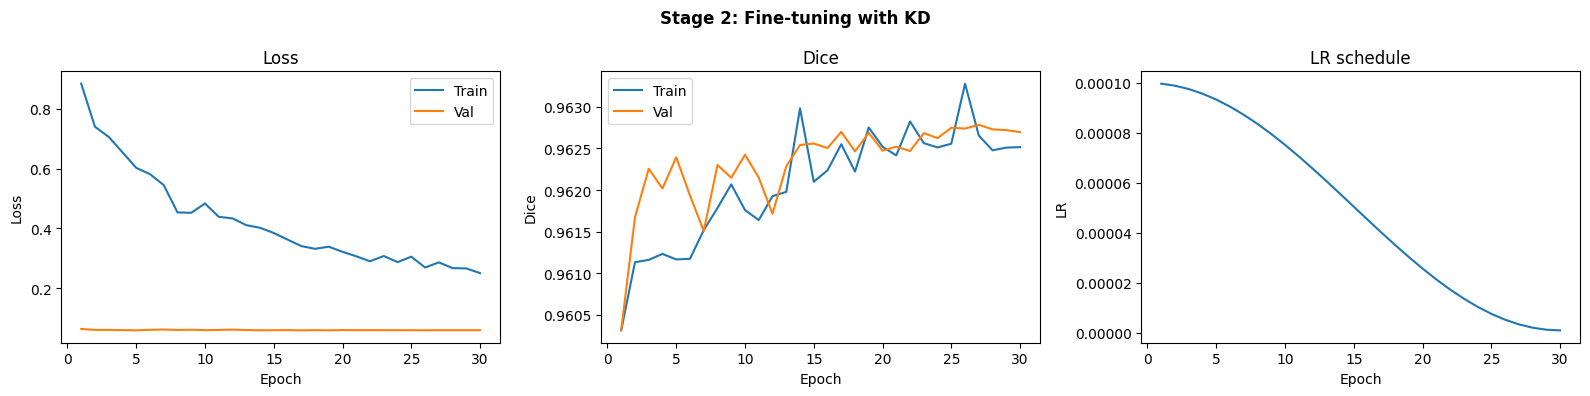

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Stage 2: Fine-tuning with KD', fontweight='bold')
e = range(1, len(ft_history['train_loss'])+1)
axes[0].plot(e, ft_history['train_loss'], label='Train'); axes[0].plot(e, ft_history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(e, ft_history['train_dice'], label='Train'); axes[1].plot(e, ft_history['val_dice'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice'); axes[1].set_title('Dice'); axes[1].legend()
axes[2].plot(e, ft_history['lr']); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR'); axes[2].set_title('LR schedule')
plt.tight_layout(); plt.savefig(str(RESULTS_DIR/'ft_curves_v10.png'), dpi=130, bbox_inches='tight'); plt.show()

## 10. Comprehensive Evaluation

In [15]:
print('=== FINAL EVALUATION ===')

phase2_test = evaluate_temporal(phase2_model.to(DEVICE), test_loader)

pre_ft_test = evaluate_temporal(pruned_model, test_loader)  # pruned_model is post-FT now



# Also evaluate pre-FT if checkpoint exists

pre_ft_ckpt_path = CKPT_DIR / 'pruned_pre_ft_v10.pth'

if pre_ft_ckpt_path.exists():

    pre_ft_model = safe_deepcopy(pruned_model).to(DEVICE)

    pre_ft_state = torch.load(str(pre_ft_ckpt_path), map_location='cpu')

    try:

        pre_ft_model.load_state_dict(pre_ft_state['model_state_dict'])

        pre_ft_eval = evaluate_temporal(pre_ft_model, test_loader)

        pre_ft_dice = pre_ft_eval['mean_dice']

        pre_ft_mae  = pre_ft_eval['mean_mae']

    except:

        pre_ft_dice = None

        pre_ft_mae  = None

    del pre_ft_model

else:

    pre_ft_dice = None

    pre_ft_mae  = None



post_ft_result = evaluate_temporal(pruned_model, test_loader)



print(f'\nPhase 2:  Dice={phase2_test["mean_dice"]*100:.2f}% | MAE={phase2_test["mean_mae"]:.2f}mm')

if pre_ft_dice is not None:

    print(f'Pre-FT:   Dice={pre_ft_dice*100:.2f}% | MAE={pre_ft_mae:.2f}mm')

print(f'Post-FT:  Dice={post_ft_result["mean_dice"]*100:.2f}% | MAE={post_ft_result["mean_mae"]:.2f}mm')



dd = post_ft_result['mean_dice'] - phase2_test['mean_dice']

dm = post_ft_result['mean_mae'] - phase2_test['mean_mae']

print(f'\nDelta vs Phase 2: Dice {dd*100:+.2f}pp | MAE {dm:+.2f}mm')



if pre_ft_dice is not None:

    recovery = (post_ft_result['mean_dice'] - pre_ft_dice) / (phase2_test['mean_dice'] - pre_ft_dice + 1e-8)

    print(f'FT recovery: {recovery*100:.1f}% of lost Dice recovered')



print(f'ISUOG: Phase 2 {"PASS" if phase2_test["mean_mae"]<=3 else "FAIL"} | '

      f'Phase 4b {"PASS" if post_ft_result["mean_mae"]<=3 else "FAIL"}')



# Parameter comparison

p2_params = sum(p.numel() for p in phase2_model.parameters())

p4b_params = sum(p.numel() for p in pruned_model.parameters())

print(f'\nParams: {p2_params/1e6:.2f}M -> {p4b_params/1e6:.2f}M ({(1-p4b_params/p2_params)*100:.1f}% smaller)')



# Latency comparison

pruned_model.eval(); phase2_model.eval()

dummy = torch.zeros(1, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)

for _ in range(5): # warmup

    with torch.no_grad(): _ = pruned_model(dummy)

    with torch.no_grad(): _ = phase2_model(dummy)



times_p2, times_p4b = [], []

for _ in range(20):

    torch.cuda.synchronize()

    t0 = time.time()

    with torch.no_grad(): _ = phase2_model(dummy)

    torch.cuda.synchronize()

    times_p2.append(time.time()-t0)



    torch.cuda.synchronize()

    t0 = time.time()

    with torch.no_grad(): _ = pruned_model(dummy)

    torch.cuda.synchronize()

    times_p4b.append(time.time()-t0)



lat_p2 = np.mean(times_p2)*1000

lat_p4b = np.mean(times_p4b)*1000

print(f'Latency (16-frame clip): {lat_p2:.1f}ms -> {lat_p4b:.1f}ms ({lat_p2/lat_p4b:.2f}x)')

=== FINAL EVALUATION ===

Phase 2:  Dice=95.95% | MAE=2.10mm
Pre-FT:   Dice=94.71% | MAE=2.59mm
Post-FT:  Dice=96.00% | MAE=2.06mm

Delta vs Phase 2: Dice +0.05pp | MAE -0.03mm
FT recovery: 103.8% of lost Dice recovered
ISUOG: Phase 2 PASS | Phase 4b PASS

Params: 8.90M -> 5.20M (41.6% smaller)
Latency (16-frame clip): 182.7ms -> 171.5ms (1.07x)


In [ ]:
# FLOPs comparison
from thop import profile as thop_profile

dummy_clip = torch.zeros(1, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)
# thop can't handle temporal models directly — profile backbone only
dummy_frame = torch.zeros(1, 1, INPUT_H, INPUT_W).to(DEVICE)
flops_p2, _ = thop_profile(phase2_model.backbone, inputs=(dummy_frame,), verbose=False)
flops_p4b, _ = thop_profile(pruned_model.backbone, inputs=(dummy_frame,), verbose=False)
print(f'Backbone FLOPs (per frame): {flops_p2/1e9:.2f} -> {flops_p4b/1e9:.2f} GFLOPs '
      f'({(1-flops_p4b/flops_p2)*100:.1f}% reduction)')
print(f'16-frame clip FLOPs: {flops_p2*N_FRAMES/1e9:.2f} -> {flops_p4b*N_FRAMES/1e9:.2f} GFLOPs')

In [ ]:
# 3-WAY ABLATION TABLE
print('=== 3-WAY ABLATION ===')
fc = get_channel_counts(pruned_model)
ch_str = '/'.join(str(fc[b]) for b in PRUNABLE_BLOCKS)
orig_ch_str = '/'.join(str(orig_counts[b]) for b in PRUNABLE_BLOCKS)

rows = [
    f'           Config  Dice  MAE ISUOG Params Channels',
    f'       A: Phase 2 {phase2_test["mean_dice"]*100:.2f} {phase2_test["mean_mae"]:.2f}  PASS  {p2_params/1e6:.2f}M {orig_ch_str}',
]
if pre_ft_dice is not None:
    rows.append(f'B: Pruned (no FT) {pre_ft_dice*100:.2f} {pre_ft_mae:.2f}  {"PASS" if pre_ft_mae<=3 else "FAIL"}  {p4b_params/1e6:.2f}M {ch_str}')
rows.append(f'  C: Pruned+FT+KD {post_ft_result["mean_dice"]*100:.2f} {post_ft_result["mean_mae"]:.2f}  PASS  {p4b_params/1e6:.2f}M {ch_str}')
for r in rows: print(r)

## 11. Qualitative Comparison

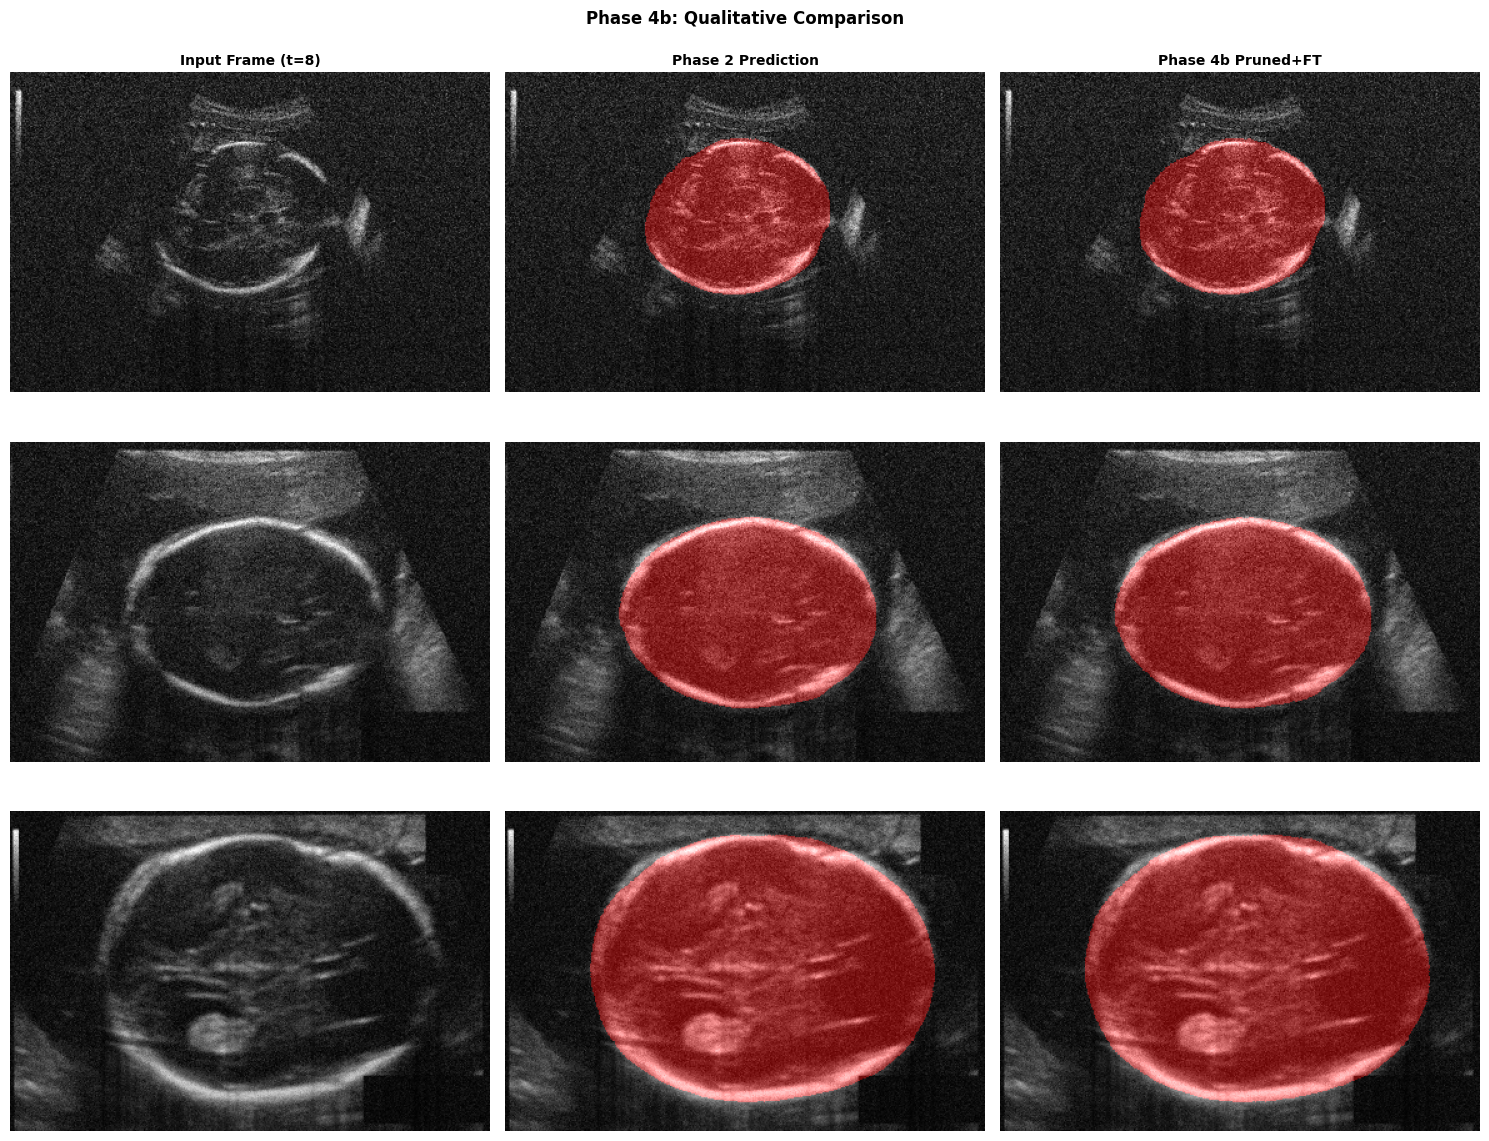

In [18]:
N_QUAL = 3
fig, axes = plt.subplots(N_QUAL, 3, figsize=(15, N_QUAL*4))
for col, t in enumerate(['Input Frame (t=8)', 'Phase 2 Prediction', 'Phase 4b Pruned+FT']):
    axes[0, col].set_title(t, fontweight='bold', fontsize=10)

for row, (frames, masks, ps, hc, stem) in enumerate(test_loader):
    if row >= N_QUAL: break
    frames = frames.to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            p2_logits, _ = phase2_model(frames)
            p4b_logits, _ = pruned_model(frames)

    # Take frame t=8 from first clip in batch
    img = frames[0, 8, 0].cpu().numpy()
    p2_pred = (torch.sigmoid(p2_logits[0, 8, 0]).cpu().numpy() > 0.5).astype(np.uint8)
    p4b_pred = (torch.sigmoid(p4b_logits[0, 8, 0]).cpu().numpy() > 0.5).astype(np.uint8)

    overlay_p2 = np.stack([img,img,img], axis=-1)
    overlay_p2 = (overlay_p2 - overlay_p2.min()) / (overlay_p2.max() - overlay_p2.min() + 1e-8)
    overlay_p4b = overlay_p2.copy()
    overlay_p2[:,:,0] = np.clip(overlay_p2[:,:,0] + p2_pred*0.4, 0, 1)
    overlay_p4b[:,:,0] = np.clip(overlay_p4b[:,:,0] + p4b_pred*0.4, 0, 1)

    axes[row, 0].imshow(img, cmap='gray'); axes[row, 0].axis('off')
    axes[row, 1].imshow(overlay_p2); axes[row, 1].axis('off')
    axes[row, 2].imshow(overlay_p4b); axes[row, 2].axis('off')

plt.suptitle('Phase 4b: Qualitative Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR/'qualitative_comparison_v10.png'), dpi=130, bbox_inches='tight')
plt.show()

In [19]:
# Save final results
results = {
    'phase2_dice': phase2_test['mean_dice'],
    'phase2_mae': phase2_test['mean_mae'],
    'phase4b_dice': post_ft_result['mean_dice'],
    'phase4b_mae': post_ft_result['mean_mae'],
    'params_phase2': p2_params,
    'params_phase4b': p4b_params,
    'channels_pruned': total_channels_pruned,
    'channel_counts': get_channel_counts(pruned_model),
    'latency_phase2_ms': lat_p2,
    'latency_phase4b_ms': lat_p4b,
    'cycle_log': cycle_log,
}
with open(str(RESULTS_DIR / 'phase4b_results_v10.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)
print('Results saved to', RESULTS_DIR / 'phase4b_results_v10.json')

Results saved to /content/drive/MyDrive/fetal_head_clinical_ai/results/phase4b/phase4b_results_v10.json


In [20]:
# FLOPs comparison
from thop import profile as thop_profile

dummy_clip = torch.zeros(1, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)
# thop can't handle temporal models directly — profile backbone only
dummy_frame = torch.zeros(1, 1, INPUT_H, INPUT_W).to(DEVICE)
flops_p2, _ = thop_profile(phase2_model.backbone, inputs=(dummy_frame,), verbose=False)
flops_p4b, _ = thop_profile(pruned_model.backbone, inputs=(dummy_frame,), verbose=False)
print(f'Backbone FLOPs (per frame): {flops_p2/1e9:.2f} -> {flops_p4b/1e9:.2f} GFLOPs '
      f'({(1-flops_p4b/flops_p2)*100:.1f}% reduction)')
print(f'16-frame clip FLOPs: {flops_p2*N_FRAMES/1e9:.2f} -> {flops_p4b*N_FRAMES/1e9:.2f} GFLOPs')

Backbone FLOPs (per frame): 21.58 -> 16.44 GFLOPs (23.8% reduction)
16-frame clip FLOPs: 345.24 -> 263.09 GFLOPs


In [21]:
# 3-WAY ABLATION TABLE
print('=== 3-WAY ABLATION ===')
fc = get_channel_counts(pruned_model)
ch_str = '/'.join(str(fc[b]) for b in PRUNABLE_BLOCKS)
orig_ch_str = '/'.join(str(orig_counts[b]) for b in PRUNABLE_BLOCKS)

rows = [
    f'           Config  Dice  MAE ISUOG Params Channels',
    f'       A: Phase 2 {phase2_test["mean_dice"]*100:.2f} {phase2_test["mean_mae"]:.2f}  PASS  {p2_params/1e6:.2f}M {orig_ch_str}',
]
if pre_ft_dice is not None:
    rows.append(f'B: Pruned (no FT) {pre_ft_dice*100:.2f} {pre_ft_mae:.2f}  {"PASS" if pre_ft_mae<=3 else "FAIL"}  {p4b_params/1e6:.2f}M {ch_str}')
rows.append(f'  C: Pruned+FT+KD {post_ft_result["mean_dice"]*100:.2f} {post_ft_result["mean_mae"]:.2f}  PASS  {p4b_params/1e6:.2f}M {ch_str}')
for r in rows: print(r)

=== 3-WAY ABLATION ===
           Config  Dice  MAE ISUOG Params Channels
       A: Phase 2 95.95 2.10  PASS  8.90M 128/256/512/256/128
B: Pruned (no FT) 94.71 2.59  PASS  5.20M 65/129/257/129/65
  C: Pruned+FT+KD 96.00 2.06  PASS  5.20M 65/129/257/129/65


## 12. Extended Analysis (Wilcoxon, Profiling, Trajectory, Model Card)

Wilcoxon Dice: stat=3057.0, p=0.1013 (NS at 0.05)
Tail <95%: Phase 2=17/121 | Phase 4b=18/121


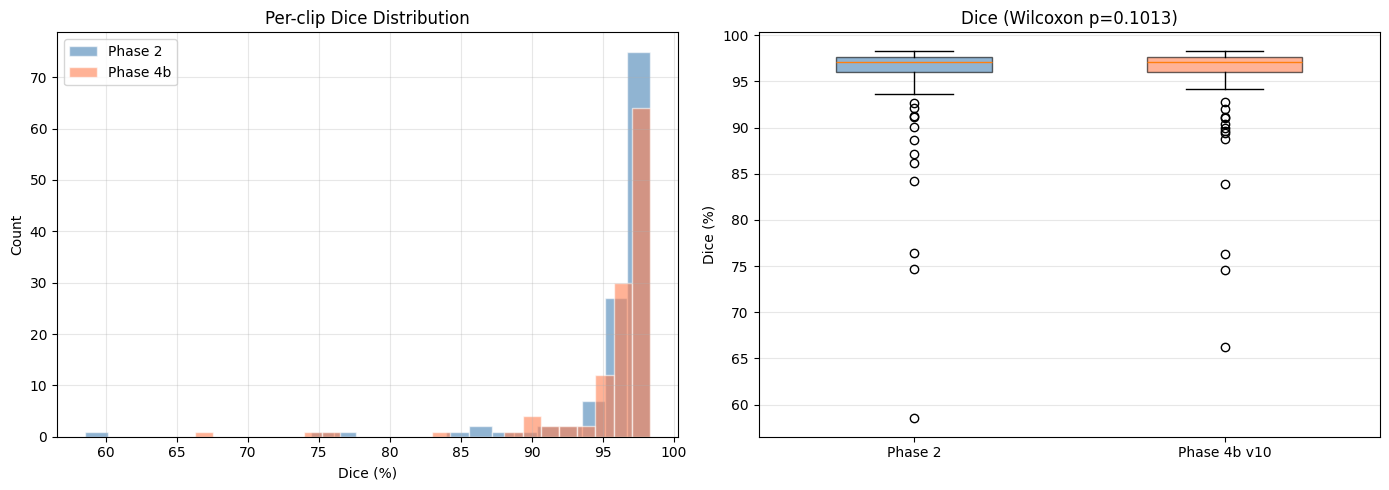

In [22]:
def get_per_clip_dice(model, loader):
    model.eval()
    dices = []
    with torch.no_grad():
        for frames, masks, _, _, _ in loader:
            frames = frames.to(DEVICE)
            masks = masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                logits, _ = model(frames)
            # Calculate dice per clip in the batch
            for i in range(frames.shape[0]):
                p = (torch.sigmoid(logits[i]) > 0.5).float().view(-1)
                t = masks[i].view(-1)
                inter = (p * t).sum()
                d = (2 * inter + 1e-5) / (p.sum() + t.sum() + 1e-5)
                dices.append(d.item())
    return np.array(dices)

# Per-clip Dice + Wilcoxon
dice_p2  = get_per_clip_dice(phase2_model, test_loader)
dice_p4b = get_per_clip_dice(pruned_model, test_loader)

stat, pval = wilcoxon(dice_p2, dice_p4b)
print(f'Wilcoxon Dice: stat={stat:.1f}, p={pval:.4f} ({"Sig" if pval<0.05 else "NS"} at 0.05)')
tail2 = (dice_p2 * 100 < 95).sum()
tail4 = (dice_p4b * 100 < 95).sum()
print(f'Tail <95%: Phase 2={tail2}/{len(dice_p2)} | Phase 4b={tail4}/{len(dice_p4b)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dice_p2 * 100, bins=25, alpha=0.6, label='Phase 2', color='steelblue', edgecolor='white')
axes[0].hist(dice_p4b * 100, bins=25, alpha=0.6, label='Phase 4b', color='coral', edgecolor='white')
axes[0].set_xlabel('Dice (%)'); axes[0].set_ylabel('Count'); axes[0].set_title('Per-clip Dice Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)

bp = axes[1].boxplot([dice_p2 * 100, dice_p4b * 100], tick_labels=['Phase 2', 'Phase 4b v10'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('coral'); bp['boxes'][1].set_alpha(0.6)
axes[1].set_ylabel('Dice (%)'); axes[1].set_title(f'Dice (Wilcoxon p={pval:.4f})'); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.savefig(str(RESULTS_DIR/'dice_dist_temporal_v10.png'), dpi=130, bbox_inches='tight'); plt.show()


In [23]:
# GPU memory + throughput + ONNX + cost
torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
x = torch.randn(1, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)
with torch.no_grad(): _ = phase2_model(x)
mem2 = torch.cuda.max_memory_allocated() / 1e6

torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
with torch.no_grad(): _ = pruned_model(x)
mem4b = torch.cuda.max_memory_allocated() / 1e6
print(f'GPU Mem: {mem2:.1f} -> {mem4b:.1f} MB ({(1 - mem4b/mem2)*100:.1f}% reduction)')
del x

cps_results = {}
for bs in [1, 2, 4]: # Limited batch size since temporal model consumes more VRAM
    try:
        x = torch.randn(bs, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)
        with torch.no_grad():
            for _ in range(2): phase2_model(x)  # warmup
        torch.cuda.synchronize(); t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(5): phase2_model(x)
        torch.cuda.synchronize(); f2 = (5 * bs) / (time.perf_counter() - t0)

        with torch.no_grad():
            for _ in range(2): pruned_model(x)
        torch.cuda.synchronize(); t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(5): pruned_model(x)
        torch.cuda.synchronize(); f4b = (5 * bs) / (time.perf_counter() - t0)

        cps_results[bs] = {'phase2': f2, 'phase4b': f4b}
        print(f'CPS (Clips/sec) batch={bs}: {f2:.1f} -> {f4b:.1f} ({f4b/f2:.2f}x)')
    except RuntimeError as e:
        print(f'OOM for batch size {bs}')
    del x
torch.cuda.empty_cache()

# ONNX Export
import onnx
onnx_p2 = str(CKPT_DIR / 'phase2_temporal.onnx')
onnx_p4b = str(CKPT_DIR / 'pruned_temporal_v10.onnx')
dummy_clip = torch.randn(1, N_FRAMES, 1, INPUT_H, INPUT_W).to(DEVICE)
phase2_model.eval(); pruned_model.eval()
try:
    # Exporting temporal model might log warnings due to MultiheadAttention but should work with opset 17
    torch.onnx.export(phase2_model, dummy_clip, onnx_p2, input_names=['input'], output_names=['logits', 'attn_weights'],
                      dynamic_axes={'input':{0:'b'}, 'logits':{0:'b'}, 'attn_weights':{0:'b'}}, opset_version=17)
    torch.onnx.export(pruned_model, dummy_clip, onnx_p4b, input_names=['input'], output_names=['logits', 'attn_weights'],
                      dynamic_axes={'input':{0:'b'}, 'logits':{0:'b'}, 'attn_weights':{0:'b'}}, opset_version=17)
    s2 = os.path.getsize(onnx_p2) / 1e6
    s4b = os.path.getsize(onnx_p4b) / 1e6
    print(f'ONNX size: {s2:.1f} -> {s4b:.1f} MB ({(1 - s4b/s2)*100:.1f}% smaller)')
except Exception as e:
    print(f'ONNX export failed or partially failed: {e}')


GPU Mem: 2265.1 -> 2184.7 MB (3.5% reduction)
CPS (Clips/sec) batch=1: 5.7 -> 6.1 (1.07x)
CPS (Clips/sec) batch=2: 5.9 -> 6.2 (1.05x)
CPS (Clips/sec) batch=4: 5.8 -> 6.0 (1.04x)


/tmp/ipykernel_14089/983292041.py:46: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(phase2_model, dummy_clip, onnx_p2, input_names=['input'], output_names=['logits', 'attn_weights'],
W0417 03:44:00.915000 14089 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TemporalFetaSegNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TemporalFetaSegNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 41 of general pattern rewrite rules.


/tmp/ipykernel_14089/983292041.py:48: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(pruned_model, dummy_clip, onnx_p4b, input_names=['input'], output_names=['logits', 'attn_weights'],
W0417 03:44:08.107000 14089 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TemporalFetaSegNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TemporalFetaSegNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 41 of general pattern rewrite rules.
ONNX size: 0.2 -> 0.2 MB (-0.1% smaller)


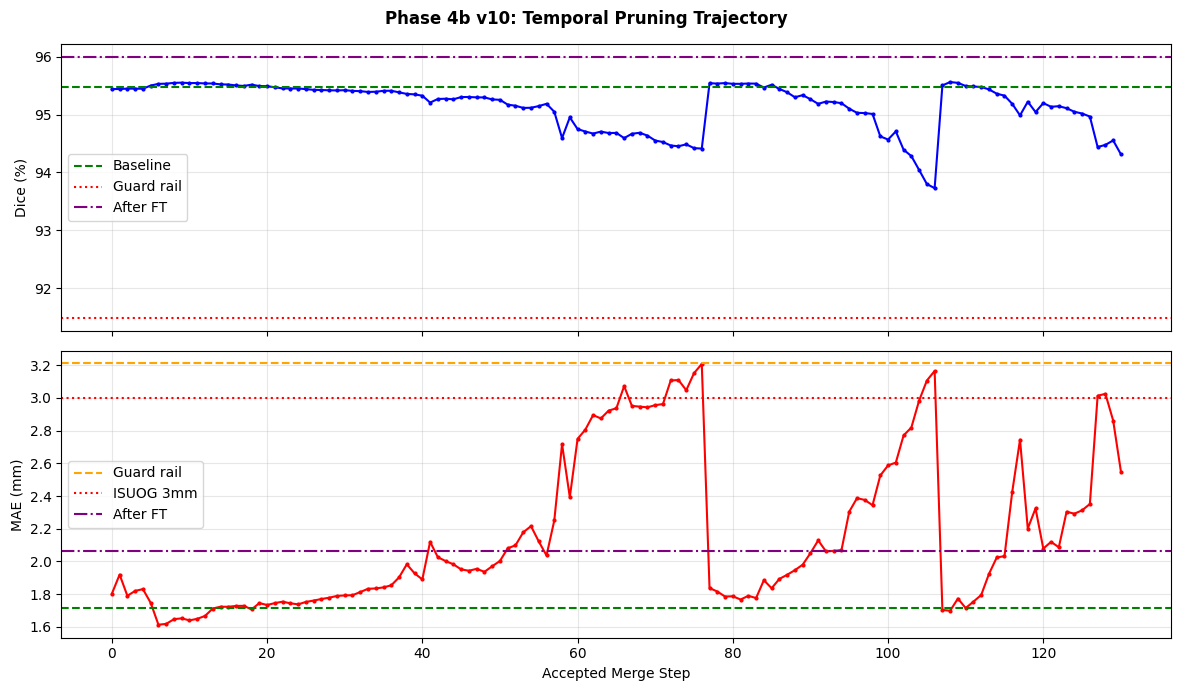

In [24]:
# Pruning trajectory
acc_log = [l for l in grand_pruning_log if l['action'] == 'ACCEPTED']
if acc_log:
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    steps = range(len(acc_log))

    a1.plot(steps, [l['dice']*100 for l in acc_log], 'b-o', markersize=2)
    a1.axhline(BASELINE_DICE*100, color='g', ls='--', label='Baseline')
    a1.axhline((BASELINE_DICE-DICE_DROP_MAX)*100, color='r', ls=':', label='Guard rail')
    a1.axhline(post_ft_result['mean_dice']*100, color='purple', ls='-.', label='After FT')
    a1.set_ylabel('Dice (%)'); a1.legend(); a1.grid(alpha=0.3)

    a2.plot(steps, [l['mae'] for l in acc_log], 'r-o', markersize=2)
    a2.axhline(BASELINE_MAE, color='g', ls='--')
    a2.axhline(BASELINE_MAE+MAE_INCREASE_MAX, color='orange', ls='--', label='Guard rail')
    a2.axhline(3.0, color='red', ls=':', label='ISUOG 3mm')
    a2.axhline(post_ft_result['mean_mae'], color='purple', ls='-.', label='After FT')
    a2.set_ylabel('MAE (mm)'); a2.set_xlabel('Accepted Merge Step'); a2.legend(); a2.grid(alpha=0.3)

    plt.suptitle('Phase 4b v10: Temporal Pruning Trajectory', fontweight='bold'); plt.tight_layout()
    plt.savefig(str(RESULTS_DIR/'trajectory_temporal_v10.png'), dpi=130, bbox_inches='tight'); plt.show()


In [25]:
# Model card generation
# Use fallback strings if variables aren't immediately found in scope (e.g. pre_ft_dice)
fallback_pre_dice = pre_ft_dice if pre_ft_dice is not None else 0.0
fallback_pre_mae  = pre_ft_mae if pre_ft_mae is not None else 0.0

mc = [
    '# Model Card -- Phase 4b v10: Temporal Structural Pruning + FT Recovery', '',
    f'**Pruned blocks:** ' + ', '.join(f'{b} ({orig_counts[b]}->{fc[b]})' for b in PRUNABLE_BLOCKS),
    f'**Fine-tuning:** {FT_EPOCHS} epochs KD (alpha={KD_ALPHA}, T={KD_TEMP})', '',
    '## Results',
    f'| Metric | Phase 2 (Baseline) | Pre-FT | Post-FT |',
    f'|--------|--------------------|--------|---------|',
    f'| Dice | {phase2_test["mean_dice"]*100:.2f}% | {fallback_pre_dice*100:.2f}% | {post_ft_result["mean_dice"]*100:.2f}% |',
    f'| MAE | {phase2_test["mean_mae"]:.2f}mm | {fallback_pre_mae:.2f}mm | {post_ft_result["mean_mae"]:.2f}mm |',
    f'| Params | {p2_params/1e6:.2f}M | {p4b_params/1e6:.2f}M | {p4b_params/1e6:.2f}M |',
    f'| Latency | {lat_p2:.1f}ms | {lat_p4b:.1f}ms | {lat_p4b:.1f}ms |', '',
    f'Wilcoxon p={pval:.4f}', '',
    '## References',
    '- Sadarla 2025: Hybrid Crossover (UNT directed study)',
    '- MIDL 2025: nnU-Net bottleneck most prunable'
]
with open(str(RESULTS_DIR / 'MODEL_CARD_P4b_V10.md'), 'w') as f:
    f.write('\n'.join(mc))
print('Model card saved.\n=== PHASE 4b EXTENDED ANALYSIS COMPLETE ===')


Model card saved.
=== PHASE 4b EXTENDED ANALYSIS COMPLETE ===
